In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [3]:
# 1) Sample mixture of 3 Gaussians in 2D
key = jax.random.PRNGKey(0)
N = 500
weights3 = jnp.array([0.3, 0.4])
means3   = jnp.array([[-2.0, -2.0],
                     [ 2.0,  2.0]])
cov_scale = 0.5

# Draw component indices
key, subkey = jax.random.split(key)
u = jax.random.uniform(subkey, (N,))
inds = jnp.searchsorted(jnp.cumsum(weights3), u)

# Sample from each Gaussian
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, (N, 2)) * cov_scale
samples = means3[inds] + eps  # shape (N,2)



In [4]:
# 2) Define target 1D mixture of 2 Gaussians
weights2 = jnp.array([0.5, 0.1])
means2   = jnp.array([-1.0, 1.0])
var2     = 0.8

key, subkey = jax.random.split(key)
u2 = jax.random.uniform(subkey, (N,))
inds2 = jnp.searchsorted(jnp.cumsum(weights2), u2)

key, subkey = jax.random.split(key)
eps2 = jax.random.normal(subkey, (N,)) * jnp.sqrt(var2)
target_samples = means2[inds2] + eps2  # shape (N,)

# Precompute target moments
mu_t  = jnp.mean(target_samples)
var_t = jnp.var(target_samples)



In [5]:
# 3a) Moment-matching loss: match mean & variance of projection y = wᵀx
def mm_loss(theta):
    w = jnp.stack([jnp.cos(theta), jnp.sin(theta)])
    y = samples @ w
    m = jnp.mean(y)
    v = jnp.var(y)
    return (m - mu_t)**2 + (v - var_t)**2

# Gradient-descent on θ
theta = 0.0
lr = 0.1
for i in range(300):
    g = jax.grad(mm_loss)(theta)
    theta -= lr * g
w_mm = jnp.stack([jnp.cos(theta), jnp.sin(theta)])
print("Moment-matching w:", w_mm)



Moment-matching w: [0.66706    0.74500394]


In [6]:
# 3b) MMD-based loss with RBF kernel
def rbf_kernel(x, y, sigma=1.0):
    sq = jnp.sum((x[:,None] - y[None,:])**2, axis=-1)
    return jnp.exp(-sq / (2 * sigma**2))

def mmd_loss(theta):
    w = jnp.stack([jnp.cos(theta), jnp.sin(theta)])
    y = samples @ w
    y = y[:,None]
    t = target_samples[:,None]
    Kxx = rbf_kernel(y, y)
    Kyy = rbf_kernel(t, t)
    Kxy = rbf_kernel(y, t)
    return jnp.mean(Kxx) + jnp.mean(Kyy) - 2*jnp.mean(Kxy)

theta2 = 0.0
lr2 = 0.1
for i in range(500):
    g2 = jax.grad(mmd_loss)(theta2)
    theta2 -= lr2 * g2
w_mmd = jnp.stack([jnp.cos(theta2), jnp.sin(theta2)])
print("MMD-matching w:", w_mmd)



MMD-matching w: [ 0.89210886 -0.45182058]


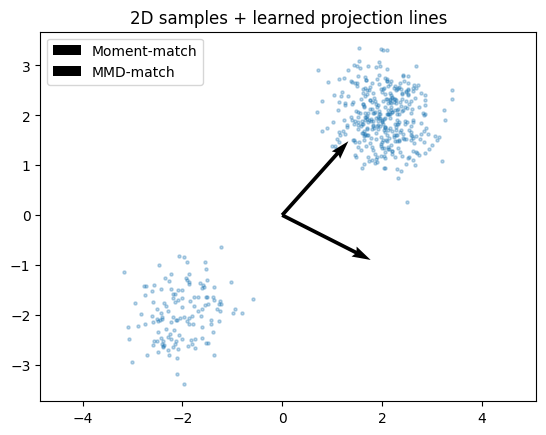

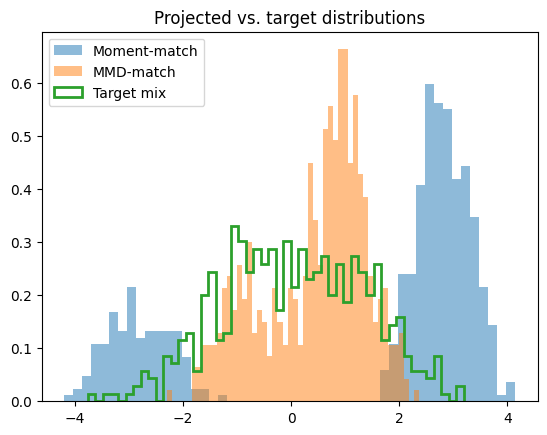

In [7]:
# Optional: visualize
plt.figure()
plt.scatter(samples[:,0], samples[:,1], alpha=0.3, s=5)
plt.quiver(0,0, *w_mm,   scale=5, label='Moment-match')
plt.quiver(0,0, *w_mmd,  scale=5, label='MMD-match')
plt.axis('equal'); plt.legend()
plt.title("2D samples + learned projection lines"); plt.show()

plt.figure()
proj_mm  = samples @ w_mm
proj_mmd = samples @ w_mmd
plt.hist(proj_mm,  bins=50, density=True, alpha=0.5, label='Moment-match')
plt.hist(proj_mmd, bins=50, density=True, alpha=0.5, label='MMD-match')
plt.hist(target_samples, bins=50, density=True,
         histtype='step', linewidth=2, label='Target mix')
plt.legend()
plt.title("Projected vs. target distributions"); plt.show()